# CBIS-DDSM EDA

## Imports

In [1]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np

## Metadata File Review

There is 2 files provided for each split:

### Train

- `datasets/cbis-ddsm-breast-cancer-image-dataset/csv/mass_case_description_train_set.csv`
- `datasets/cbis-ddsm-breast-cancer-image-dataset/csv/calc_case_description_train_set.csv`

### Test

- `datasets/cbis-ddsm-breast-cancer-image-dataset/csv/mass_case_description_test_set.csv`
- `datasets/cbis-ddsm-breast-cancer-image-dataset/csv/calc_case_description_test_set.csv`


And 2 meta files:

- `datasets/cbis-ddsm-breast-cancer-image-dataset/csv/dicom_info.csv`
- `datasets/cbis-ddsm-breast-cancer-image-dataset/csv/meta.csv`

In [2]:
train_set_mass_df = pd.read_csv("../datasets/cbis-ddsm-breast-cancer-image-dataset/csv/mass_case_description_train_set.csv")
train_set_mass_df.head()

,patient_id,breast_density,left or right breast,image view,abnormality id,abnormality type,mass shape,mass margins,assessment,pathology,subtlety,image file path,cropped image file path,ROI mask file path
0,P_00001,3,LEFT,CC,1,mass,IRREGULAR-ARCHITECTURAL_DISTORTION,SPICULATED,4,MALIGNANT,4,Mass-Training_P_00001_LEFT_CC/1.3.6.1.4.1.9590...,Mass-Training_P_00001_LEFT_CC_1/1.3.6.1.4.1.95...,Mass-Training_P_00001_LEFT_CC_1/1.3.6.1.4.1.95...
1,P_00001,3,LEFT,MLO,1,mass,IRREGULAR-ARCHITECTURAL_DISTORTION,SPICULATED,4,MALIGNANT,4,Mass-Training_P_00001_LEFT_MLO/1.3.6.1.4.1.959...,Mass-Training_P_00001_LEFT_MLO_1/1.3.6.1.4.1.9...,Mass-Training_P_00001_LEFT_MLO_1/1.3.6.1.4.1.9...
2,P_00004,3,LEFT,CC,1,mass,ARCHITECTURAL_DISTORTION,ILL_DEFINED,4,BENIGN,3,Mass-Training_P_00004_LEFT_CC/1.3.6.1.4.1.9590...,Mass-Training_P_00004_LEFT_CC_1/1.3.6.1.4.1.95...,Mass-Training_P_00004_LEFT_CC_1/1.3.6.1.4.1.95...
3,P_00004,3,LEFT,MLO,1,mass,ARCHITECTURAL_DISTORTION,ILL_DEFINED,4,BENIGN,3,Mass-Training_P_00004_LEFT_MLO/1.3.6.1.4.1.959...,Mass-Training_P_00004_LEFT_MLO_1/1.3.6.1.4.1.9...,Mass-Training_P_00004_LEFT_MLO_1/1.3.6.1.4.1.9...
4,P_00004,3,RIGHT,MLO,1,mass,OVAL,CIRCUMSCRIBED,4,BENIGN,5,Mass-Training_P_00004_RIGHT_MLO/1.3.6.1.4.1.95...,Mass-Training_P_00004_RIGHT_MLO_1/1.3.6.1.4.1....,Mass-Training_P_00004_RIGHT_MLO_1/1.3.6.1.4.1....


In [3]:
test_set_mass_df = pd.read_csv("../datasets/cbis-ddsm-breast-cancer-image-dataset/csv/mass_case_description_test_set.csv")

In [4]:
train_set_calc_df = pd.read_csv("../datasets/cbis-ddsm-breast-cancer-image-dataset/csv/calc_case_description_train_set.csv")
train_set_calc_df.head()

,patient_id,breast density,left or right breast,image view,abnormality id,abnormality type,calc type,calc distribution,assessment,pathology,subtlety,image file path,cropped image file path,ROI mask file path
0,P_00005,3,RIGHT,CC,1,calcification,AMORPHOUS,CLUSTERED,3,MALIGNANT,3,Calc-Training_P_00005_RIGHT_CC/1.3.6.1.4.1.959...,Calc-Training_P_00005_RIGHT_CC_1/1.3.6.1.4.1.9...,Calc-Training_P_00005_RIGHT_CC_1/1.3.6.1.4.1.9...
1,P_00005,3,RIGHT,MLO,1,calcification,AMORPHOUS,CLUSTERED,3,MALIGNANT,3,Calc-Training_P_00005_RIGHT_MLO/1.3.6.1.4.1.95...,Calc-Training_P_00005_RIGHT_MLO_1/1.3.6.1.4.1....,Calc-Training_P_00005_RIGHT_MLO_1/1.3.6.1.4.1....
2,P_00007,4,LEFT,CC,1,calcification,PLEOMORPHIC,LINEAR,4,BENIGN,4,Calc-Training_P_00007_LEFT_CC/1.3.6.1.4.1.9590...,Calc-Training_P_00007_LEFT_CC_1/1.3.6.1.4.1.95...,Calc-Training_P_00007_LEFT_CC_1/1.3.6.1.4.1.95...
3,P_00007,4,LEFT,MLO,1,calcification,PLEOMORPHIC,LINEAR,4,BENIGN,4,Calc-Training_P_00007_LEFT_MLO/1.3.6.1.4.1.959...,Calc-Training_P_00007_LEFT_MLO_1/1.3.6.1.4.1.9...,Calc-Training_P_00007_LEFT_MLO_1/1.3.6.1.4.1.9...
4,P_00008,1,LEFT,CC,1,calcification,NaN,REGIONAL,2,BENIGN_WITHOUT_CALLBACK,3,Calc-Training_P_00008_LEFT_CC/1.3.6.1.4.1.9590...,Calc-Training_P_00008_LEFT_CC_1/1.3.6.1.4.1.95...,Calc-Training_P_00008_LEFT_CC_1/1.3.6.1.4.1.95...


In [5]:
test_set_calc_df = pd.read_csv("../datasets/cbis-ddsm-breast-cancer-image-dataset/csv/calc_case_description_test_set.csv")

In [6]:
dicom_info_df = pd.read_csv("../datasets/cbis-ddsm-breast-cancer-image-dataset/csv/dicom_info.csv")
dicom_info_df.head()

,file_path,image_path,AccessionNumber,BitsAllocated,BitsStored,BodyPartExamined,Columns,ContentDate,ContentTime,ConversionType,...,SecondaryCaptureDeviceManufacturerModelName,SeriesDescription,SeriesInstanceUID,SeriesNumber,SmallestImagePixelValue,SpecificCharacterSet,StudyDate,StudyID,StudyInstanceUID,StudyTime
0,CBIS-DDSM/dicom/1.3.6.1.4.1.9590.100.1.2.12930...,CBIS-DDSM/jpeg/1.3.6.1.4.1.9590.100.1.2.129308...,NaN,16,16,BREAST,351,20160426,131732.685,WSD,...,MATLAB,cropped images,1.3.6.1.4.1.9590.100.1.2.129308726812851964007...,1,23078,ISO_IR 100,20160720.0,DDSM,1.3.6.1.4.1.9590.100.1.2.271867287611061855725...,214951.0
1,CBIS-DDSM/dicom/1.3.6.1.4.1.9590.100.1.2.24838...,CBIS-DDSM/jpeg/1.3.6.1.4.1.9590.100.1.2.248386...,NaN,16,16,BREAST,3526,20160426,143829.101,WSD,...,MATLAB,full mammogram images,1.3.6.1.4.1.9590.100.1.2.248386742010678582309...,1,0,ISO_IR 100,20160720.0,DDSM,1.3.6.1.4.1.9590.100.1.2.161516517311681906612...,193426.0
2,CBIS-DDSM/dicom/1.3.6.1.4.1.9590.100.1.2.26721...,CBIS-DDSM/jpeg/1.3.6.1.4.1.9590.100.1.2.267213...,NaN,16,16,BREAST,1546,20160503,111956.298,WSD,...,MATLAB,full mammogram images,1.3.6.1.4.1.9590.100.1.2.267213171011171858918...,1,0,ISO_IR 100,20160807.0,DDSM,1.3.6.1.4.1.9590.100.1.2.291043622711253836701...,161814.0
3,CBIS-DDSM/dicom/1.3.6.1.4.1.9590.100.1.2.38118...,CBIS-DDSM/jpeg/1.3.6.1.4.1.9590.100.1.2.381187...,NaN,16,16,BREAST,97,20160503,115347.770,WSD,...,MATLAB,cropped images,1.3.6.1.4.1.9590.100.1.2.381187369611524586537...,1,32298,ISO_IR 100,20170829.0,DDSM,1.3.6.1.4.1.9590.100.1.2.335006093711888937440...,180109.0
4,CBIS-DDSM/dicom/1.3.6.1.4.1.9590.100.1.2.38118...,CBIS-DDSM/jpeg/1.3.6.1.4.1.9590.100.1.2.381187...,NaN,8,8,Left Breast,3104,20160503,115347.770,WSD,...,MATLAB,NaN,1.3.6.1.4.1.9590.100.1.2.381187369611524586537...,1,0,ISO_IR 100,NaN,DDSM,1.3.6.1.4.1.9590.100.1.2.335006093711888937440...,NaN


In [7]:
meta_df = pd.read_csv("../datasets/cbis-ddsm-breast-cancer-image-dataset/csv/meta.csv")
meta_df.head()

,SeriesInstanceUID,StudyInstanceUID,Modality,SeriesDescription,BodyPartExamined,SeriesNumber,Collection,Visibility,ImageCount
0,1.3.6.1.4.1.9590.100.1.2.117041576511324414842...,1.3.6.1.4.1.9590.100.1.2.229361142710768138411...,MG,ROI mask images,BREAST,1,CBIS-DDSM,1,2
1,1.3.6.1.4.1.9590.100.1.2.438738396107617880132...,1.3.6.1.4.1.9590.100.1.2.195593486612988388325...,MG,ROI mask images,BREAST,1,CBIS-DDSM,1,2
2,1.3.6.1.4.1.9590.100.1.2.767416741131676463382...,1.3.6.1.4.1.9590.100.1.2.257901172612530623323...,MG,ROI mask images,BREAST,1,CBIS-DDSM,1,2
3,1.3.6.1.4.1.9590.100.1.2.296931352612305599800...,1.3.6.1.4.1.9590.100.1.2.109468616710242115222...,MG,ROI mask images,BREAST,1,CBIS-DDSM,1,2
4,1.3.6.1.4.1.9590.100.1.2.436657670120353100077...,1.3.6.1.4.1.9590.100.1.2.380627129513562450304...,MG,ROI mask images,BREAST,1,CBIS-DDSM,1,2


The paper claims that there's 891 mass cases, for some reason we appear to have 892 in the dataset.

In [8]:
len(set(train_set_mass_df.patient_id.unique()) | set(test_set_mass_df.patient_id.unique()))

892

However, we have the correct number of calcification cases.

In [9]:
test_set_calc_df.patient_id.nunique() + train_set_calc_df.patient_id.nunique()

753

Let's have a closer look at one patient id to start with. Later we'll try to understand stastics for all patient ids.

In [10]:
patient_5 = train_set_calc_df[train_set_calc_df.patient_id == "P_00005"]

In [11]:
patient_5.iloc[0]

patient_id                                                           P_00005
breast density                                                             3
left or right breast                                                   RIGHT
image view                                                                CC
abnormality id                                                             1
abnormality type                                               calcification
calc type                                                          AMORPHOUS
calc distribution                                                  CLUSTERED
assessment                                                                 3
pathology                                                          MALIGNANT
subtlety                                                                   3
image file path            Calc-Training_P_00005_RIGHT_CC/1.3.6.1.4.1.959...
cropped image file path    Calc-Training_P_00005_RIGHT_CC_1/1.3.6.1.4.1.9...

## Image Extraction

Each row, which represents a view of the patient's breast contains 3 dicom files:

- image file path
- ROI mask file path
- cropped image file path

The creator of the CBIS-DDSM JPG dataset has converted each of these files into jpg files, which can be retrieve by extracting the dicom id from the path, and then looking it up in the `dicom_info_df` file.

Firstly, need a function to extract the Dicom id from the path

In [12]:
def get_img_id_from_dcm_file(path: Path):
    return str(path).split("/")[1]

### Fetch img file path

Now to fetch the id for the "image file path":

In [13]:
patient_5_img_file = patient_5.iloc[0]["image file path"]
patient_5_img_file

'Calc-Training_P_00005_RIGHT_CC/1.3.6.1.4.1.9590.100.1.2.408909860712120272633130274602115723157/1.3.6.1.4.1.9590.100.1.2.47414316010368386519740343172775938548/000000.dcm'

In [14]:
patient_5_img_id = get_img_id_from_dcm_file(patient_5_img_file)
patient_5_img_id

'1.3.6.1.4.1.9590.100.1.2.408909860712120272633130274602115723157'

In [16]:
dicom_5_row = dicom_info_df[dicom_info_df.StudyInstanceUID == patient_5_img_id].iloc[0]
dicom_5_row.image_path

'CBIS-DDSM/jpeg/1.3.6.1.4.1.9590.100.1.2.47414316010368386519740343172775938548/1-188.jpg'

In [17]:
JPEG_ROOT = Path("../datasets/cbis-ddsm-breast-cancer-image-dataset/jpeg")

Now a function to normalise the JPEG path to use my path:

In [18]:
def get_jpg_path(img_file_path: str):
    return JPEG_ROOT / img_file_path.replace("CBIS-DDSM/jpeg/", "")

In [19]:
patient_img = Image.open(get_jpg_path(dicom_5_row.image_path))

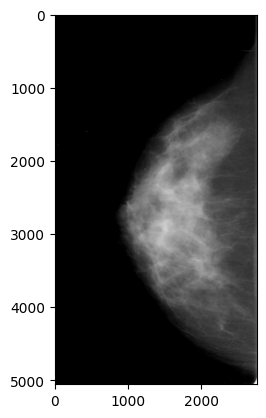

In [20]:
plt.imshow(patient_img, cmap="grey")

Now to wrap all that in a single function.

In [21]:
def get_img_path(img_path):
    img_file = get_img_id_from_dcm_file(img_path)
    dicom_row = dicom_info_df[dicom_info_df.StudyInstanceUID == img_file].iloc[0]
    return get_jpg_path(dicom_row.image_path)

### Fetch ROI mask file path

In [22]:
mask_img_path = get_img_path(patient_5.iloc[0]["ROI mask file path"])
mask_img = Image.open(mask_img_path)

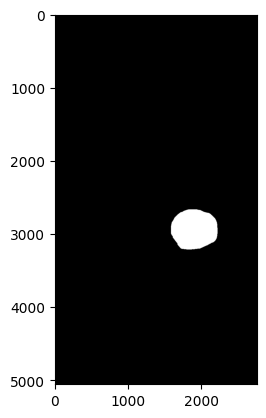

In [23]:
plt.imshow(mask_img, cmap="grey")

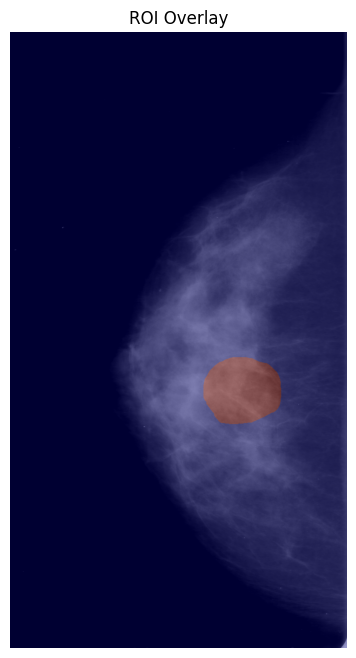

In [26]:
patient_np = np.array(patient_img)
mask_np = np.array(mask_img)

plt.figure(figsize=(8,8))
plt.imshow(patient_np, cmap='gray')

# overlay mask with transparency
plt.imshow(mask_np, cmap='jet', alpha=0.4)

plt.axis("off")
plt.title("ROI Overlay")
plt.show()

### Fetch cropped img path

To get the cropped image, it seems we need to fetch it relative to the ROI mask.

In [27]:
def get_cropped_img_from_roi_path(mask_img_path):
    parent_dir = mask_img_path.parent 
    files = list(parent_dir.glob("*.jpg"))
    crop = [f for f in files if f.name.startswith("2-")][0]
    return crop

In [28]:
cropped_img_path = get_cropped_img_from_roi_path(mask_img_path)
cropped_img_path

PosixPath('../datasets/cbis-ddsm-breast-cancer-image-dataset/jpeg/1.3.6.1.4.1.9590.100.1.2.393344010211719049419601138200355094682/2-191.jpg')

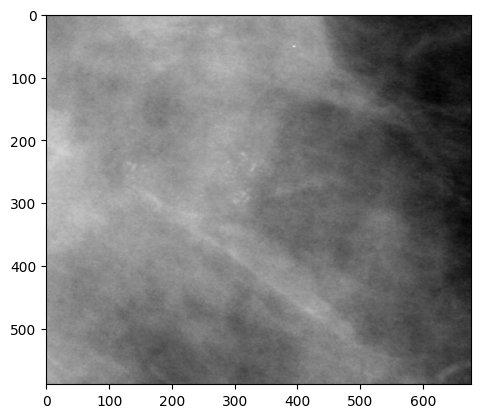

In [29]:
plt.imshow(Image.open(cropped_img_path), cmap="grey")

## EDA

Firstly, we'll take a look at the label distribution.

### Combine all data for label analysis

In [30]:
# Combine train and test sets for comprehensive analysis
all_mass_df = pd.concat([train_set_mass_df, test_set_mass_df], ignore_index=True)
all_calc_df = pd.concat([train_set_calc_df, test_set_calc_df], ignore_index=True)

# Add abnormality type column for combined analysis
all_mass_df['abnormality_category'] = 'mass'
all_calc_df['abnormality_category'] = 'calcification'

# Combine both mass and calc data
all_data_df = pd.concat([all_mass_df, all_calc_df], ignore_index=True)

print(f"Total number of cases: {len(all_data_df)}")
print(f"Mass cases: {len(all_mass_df)}")
print(f"Calcification cases: {len(all_calc_df)}")

Total number of cases: 3568
Mass cases: 1696
Calcification cases: 1872


### Pathology Distribution

The most important label is `pathology`, which indicates whether the abnormality is benign or malignant.

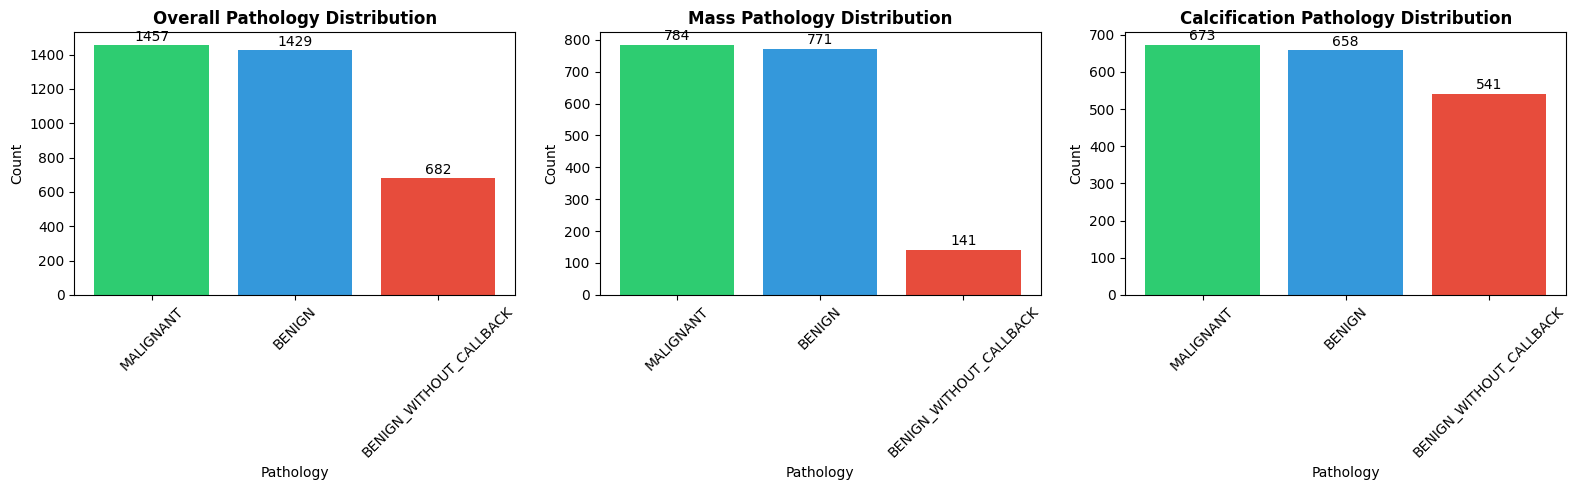

In [31]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Overall pathology distribution
pathology_counts = all_data_df['pathology'].value_counts()
axes[0].bar(pathology_counts.index, pathology_counts.values, color=['#2ecc71', '#3498db', '#e74c3c'])
axes[0].set_title('Overall Pathology Distribution', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Pathology')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)
for i, v in enumerate(pathology_counts.values):
    axes[0].text(i, v + 5, str(v), ha='center', va='bottom')

# Mass pathology distribution
mass_pathology = all_mass_df['pathology'].value_counts()
axes[1].bar(mass_pathology.index, mass_pathology.values, color=['#2ecc71', '#3498db', '#e74c3c'])
axes[1].set_title('Mass Pathology Distribution', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Pathology')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=45)
for i, v in enumerate(mass_pathology.values):
    axes[1].text(i, v + 5, str(v), ha='center', va='bottom')

# Calcification pathology distribution
calc_pathology = all_calc_df['pathology'].value_counts()
axes[2].bar(calc_pathology.index, calc_pathology.values, color=['#2ecc71', '#3498db', '#e74c3c'])
axes[2].set_title('Calcification Pathology Distribution', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Pathology')
axes[2].set_ylabel('Count')
axes[2].tick_params(axis='x', rotation=45)
for i, v in enumerate(calc_pathology.values):
    axes[2].text(i, v + 5, str(v), ha='center', va='bottom')

plt.tight_layout()
plt.show()

### BI-RADS Assessment Distribution

The BI-RADS assessment category (0-5) indicates the level of suspicion.

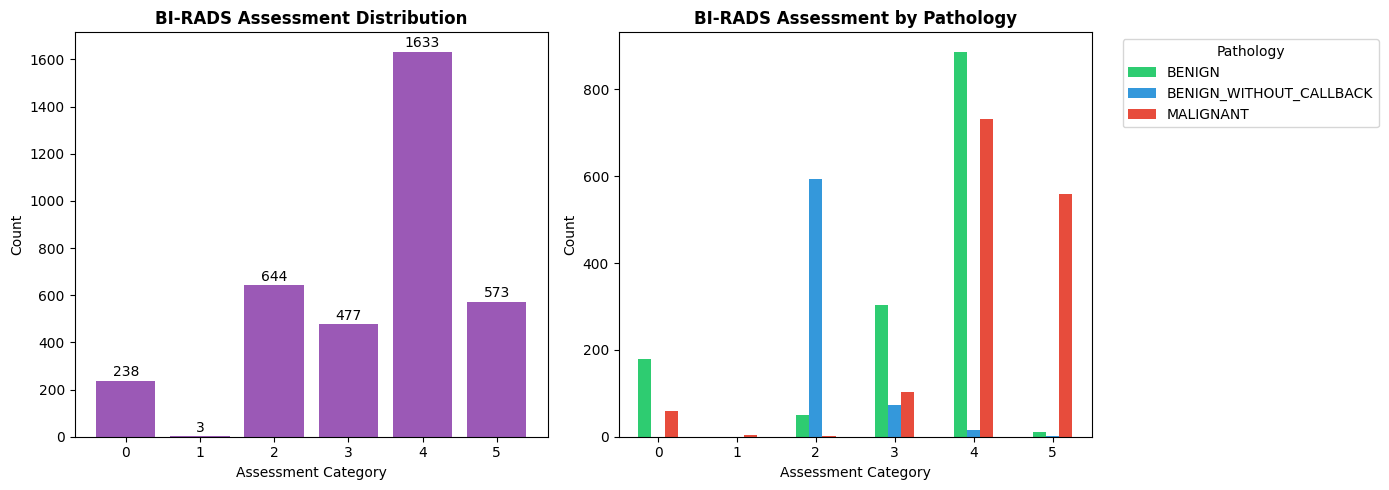

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Overall assessment distribution
assessment_counts = all_data_df['assessment'].value_counts().sort_index()
axes[0].bar(assessment_counts.index.astype(str), assessment_counts.values, color='#9b59b6')
axes[0].set_title('BI-RADS Assessment Distribution', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Assessment Category')
axes[0].set_ylabel('Count')
for i, (idx, v) in enumerate(assessment_counts.items()):
    axes[0].text(i, v + 5, str(v), ha='center', va='bottom')

# Assessment by pathology
pathology_assessment = pd.crosstab(all_data_df['assessment'], all_data_df['pathology'])
pathology_assessment.plot(kind='bar', ax=axes[1], color=['#2ecc71', '#3498db', '#e74c3c'])
axes[1].set_title('BI-RADS Assessment by Pathology', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Assessment Category')
axes[1].set_ylabel('Count')
axes[1].legend(title='Pathology', bbox_to_anchor=(1.05, 1), loc='upper left')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

### Abnormality Type Distribution

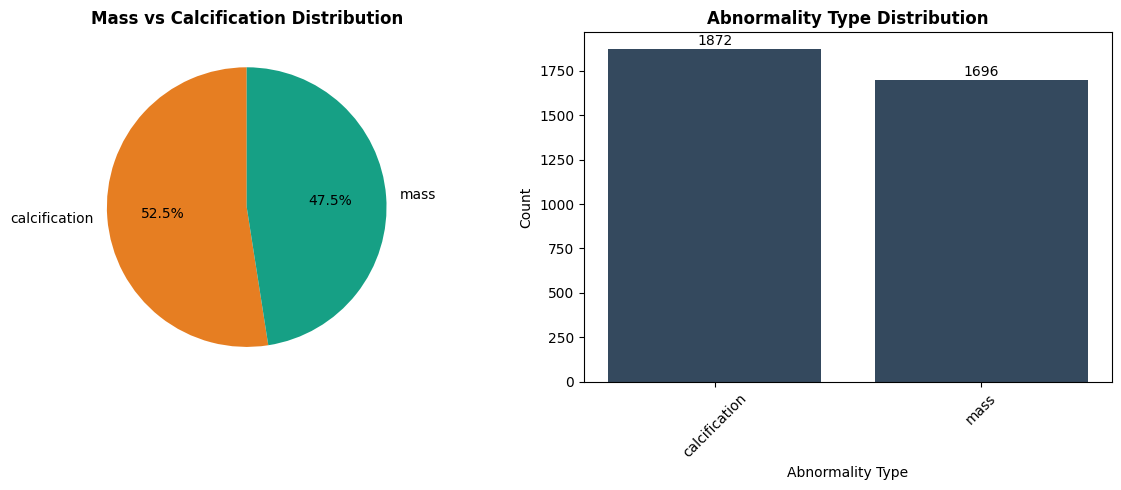

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Abnormality category
abnormality_counts = all_data_df['abnormality_category'].value_counts()
axes[0].pie(abnormality_counts.values, labels=abnormality_counts.index, autopct='%1.1f%%',
            colors=['#e67e22', '#16a085'], startangle=90)
axes[0].set_title('Mass vs Calcification Distribution', fontsize=12, fontweight='bold')

# Abnormality type (from the original column)
abnormality_type_counts = all_data_df['abnormality type'].value_counts()
axes[1].bar(abnormality_type_counts.index, abnormality_type_counts.values, color='#34495e')
axes[1].set_title('Abnormality Type Distribution', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Abnormality Type')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=45)
for i, v in enumerate(abnormality_type_counts.values):
    axes[1].text(i, v + 5, str(v), ha='center', va='bottom')

plt.tight_layout()
plt.show()

### Mass Shape and Margins Distribution

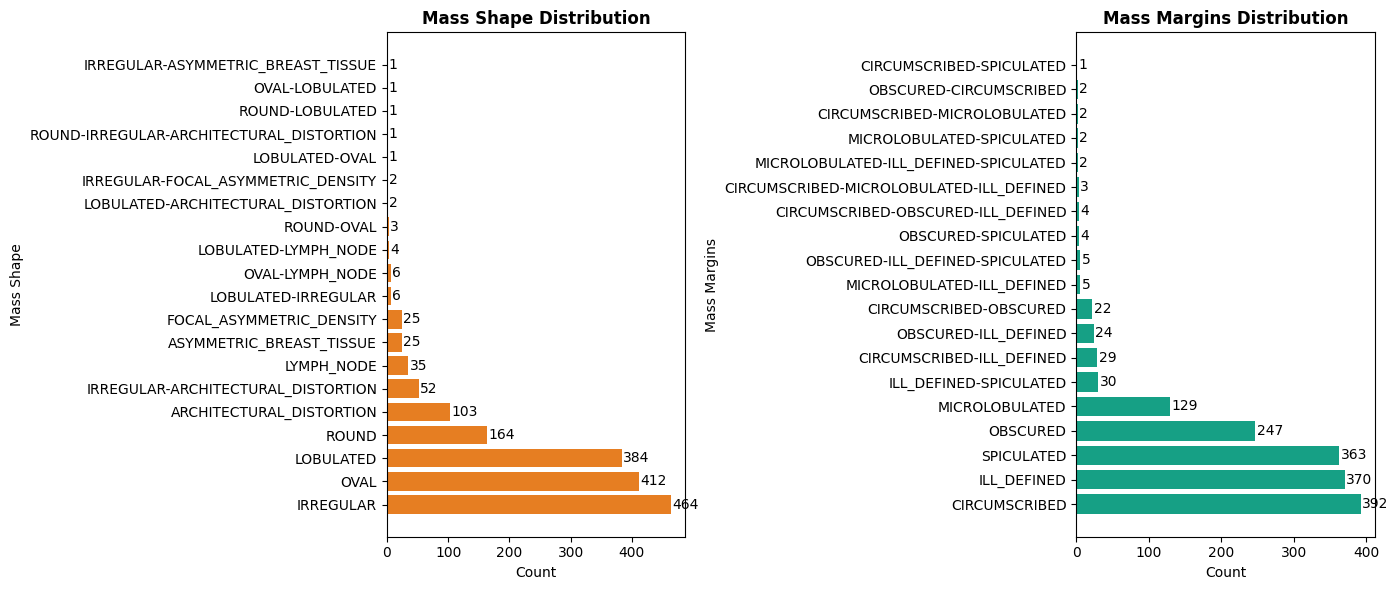

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Mass shape
mass_shape_counts = all_mass_df['mass shape'].value_counts()
axes[0].barh(mass_shape_counts.index, mass_shape_counts.values, color='#e67e22')
axes[0].set_title('Mass Shape Distribution', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Count')
axes[0].set_ylabel('Mass Shape')
for i, v in enumerate(mass_shape_counts.values):
    axes[0].text(v + 2, i, str(v), va='center')

# Mass margins
mass_margins_counts = all_mass_df['mass margins'].value_counts()
axes[1].barh(mass_margins_counts.index, mass_margins_counts.values, color='#16a085')
axes[1].set_title('Mass Margins Distribution', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Count')
axes[1].set_ylabel('Mass Margins')
for i, v in enumerate(mass_margins_counts.values):
    axes[1].text(v + 2, i, str(v), va='center')

plt.tight_layout()
plt.show()

### Calcification Type and Distribution

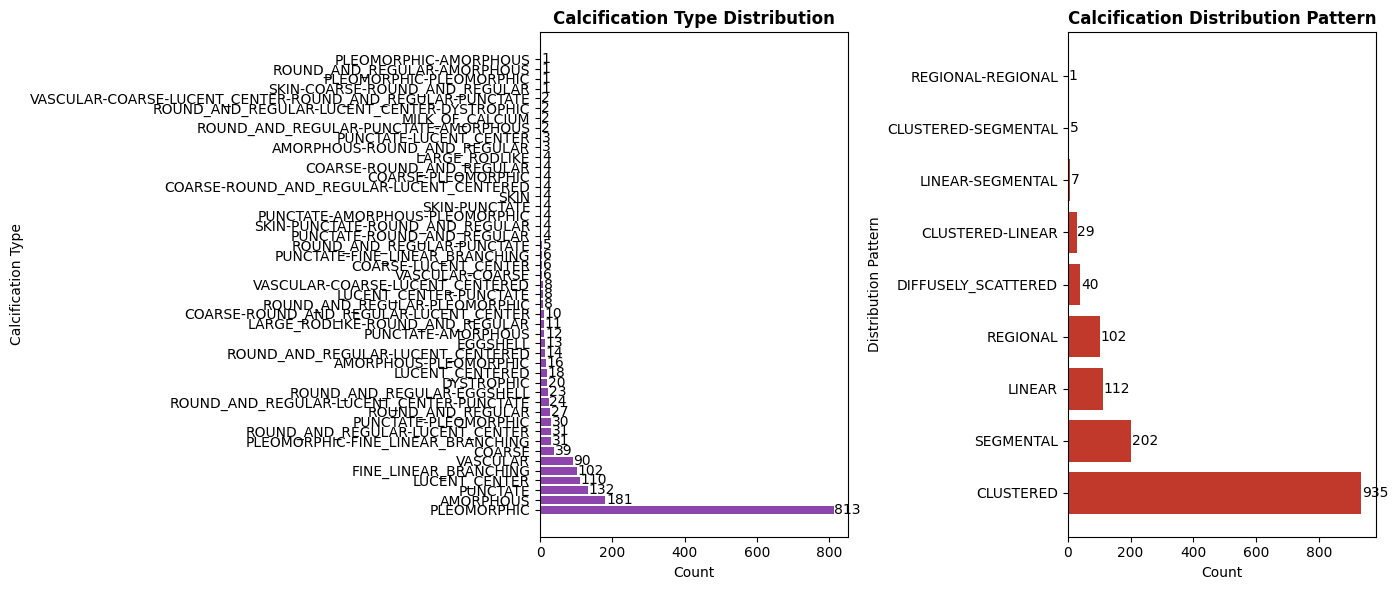

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Calc type
calc_type_counts = all_calc_df['calc type'].value_counts()
axes[0].barh(calc_type_counts.index, calc_type_counts.values, color='#8e44ad')
axes[0].set_title('Calcification Type Distribution', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Count')
axes[0].set_ylabel('Calcification Type')
for i, v in enumerate(calc_type_counts.values):
    axes[0].text(v + 2, i, str(v), va='center')

# Calc distribution
calc_dist_counts = all_calc_df['calc distribution'].value_counts()
axes[1].barh(calc_dist_counts.index, calc_dist_counts.values, color='#c0392b')
axes[1].set_title('Calcification Distribution Pattern', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Count')
axes[1].set_ylabel('Distribution Pattern')
for i, v in enumerate(calc_dist_counts.values):
    axes[1].text(v + 2, i, str(v), va='center')

plt.tight_layout()
plt.show()

### Breast Density Distribution

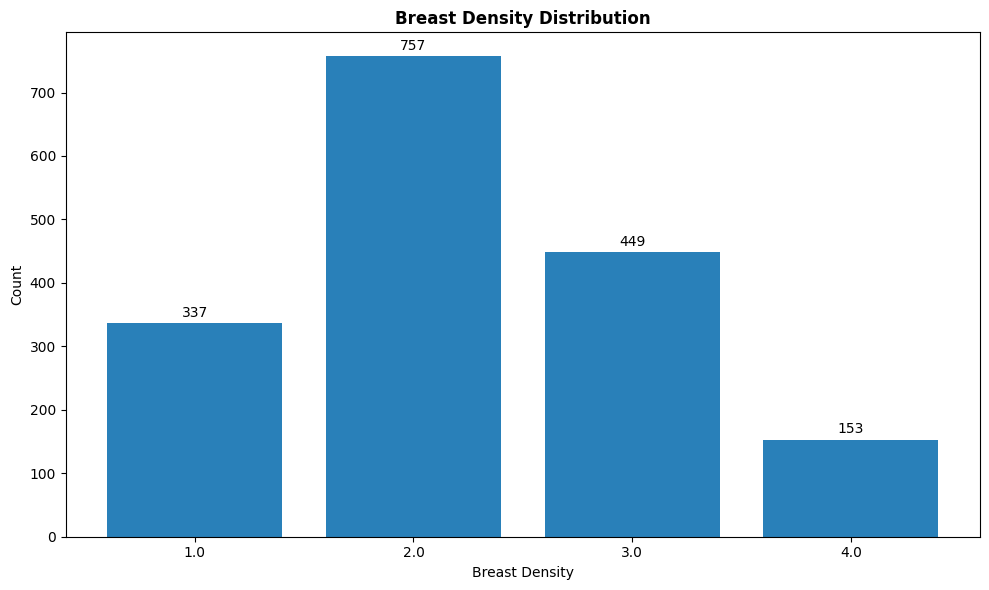

In [36]:
fig, ax = plt.subplots(figsize=(10, 6))

# Handle both column name formats
density_col = 'breast_density' if 'breast_density' in all_data_df.columns else 'breast density'
breast_density_counts = all_data_df[density_col].value_counts().sort_index()

ax.bar(breast_density_counts.index.astype(str), breast_density_counts.values, color='#2980b9')
ax.set_title('Breast Density Distribution', fontsize=12, fontweight='bold')
ax.set_xlabel('Breast Density')
ax.set_ylabel('Count')
for i, v in enumerate(breast_density_counts.values):
    ax.text(i, v + 5, str(v), ha='center', va='bottom')

plt.tight_layout()
plt.show()

### Subtlety Distribution

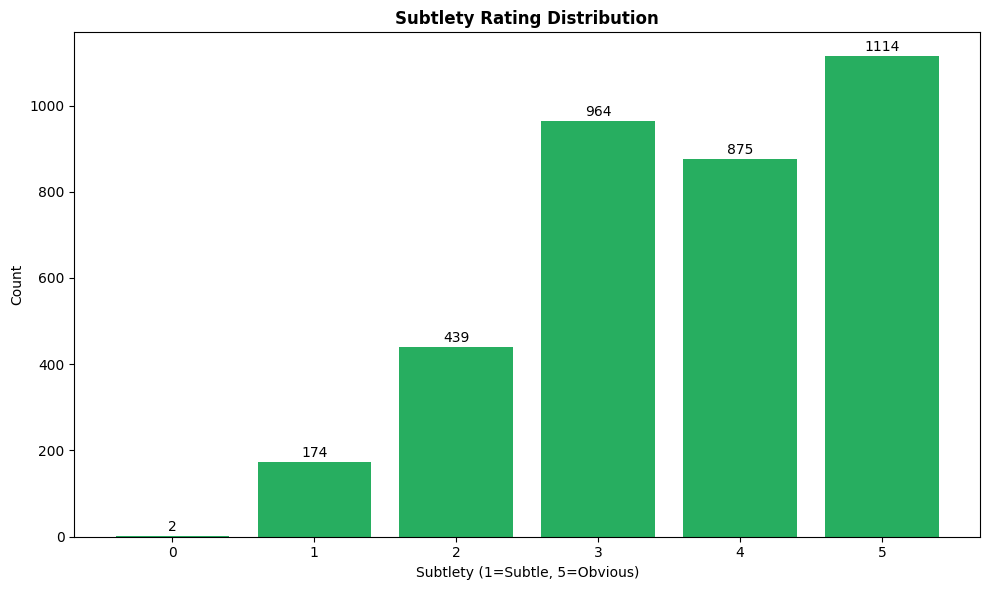

In [37]:
fig, ax = plt.subplots(figsize=(10, 6))

subtlety_counts = all_data_df['subtlety'].value_counts().sort_index()
ax.bar(subtlety_counts.index.astype(str), subtlety_counts.values, color='#27ae60')
ax.set_title('Subtlety Rating Distribution', fontsize=12, fontweight='bold')
ax.set_xlabel('Subtlety (1=Subtle, 5=Obvious)')
ax.set_ylabel('Count')
for i, v in enumerate(subtlety_counts.values):
    ax.text(i, v + 5, str(v), ha='center', va='bottom')

plt.tight_layout()
plt.show()

### Image View Distribution

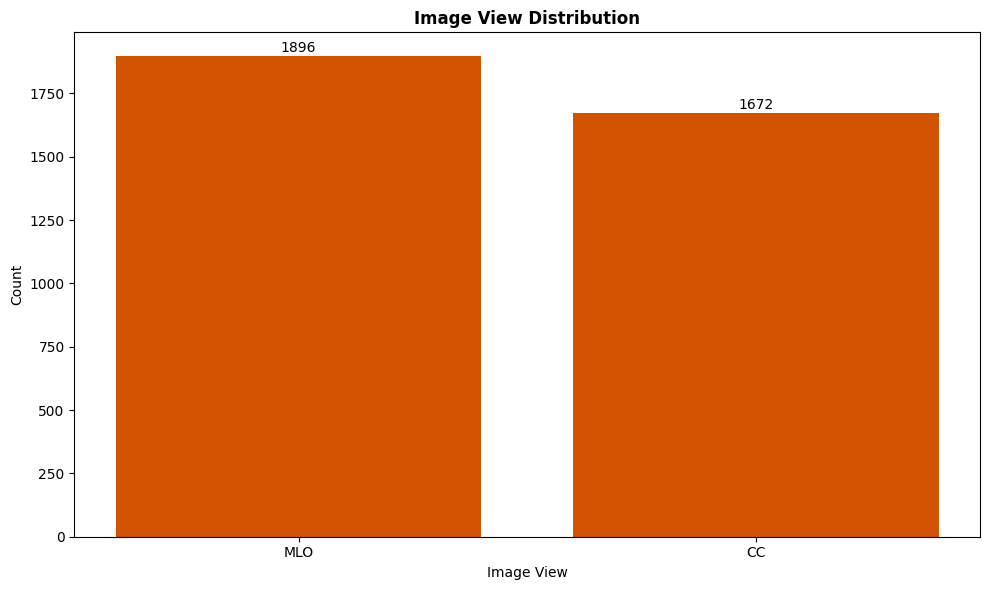

In [38]:
fig, ax = plt.subplots(figsize=(10, 6))

view_counts = all_data_df['image view'].value_counts()
ax.bar(view_counts.index, view_counts.values, color='#d35400')
ax.set_title('Image View Distribution', fontsize=12, fontweight='bold')
ax.set_xlabel('Image View')
ax.set_ylabel('Count')
for i, v in enumerate(view_counts.values):
    ax.text(i, v + 5, str(v), ha='center', va='bottom')

plt.tight_layout()
plt.show()